In [1]:
!pip install db-dtypes

In [2]:
from google.cloud import bigquery
import pandas as pd

client = bigquery.Client(project="ga4-portfolio-audit")

query = """
    SELECT
        FORMAT_DATE('%Y-%m', PARSE_DATE('%Y%m%d', event_date)) AS month,
        COUNT(DISTINCT user_pseudo_id) AS total_users
    FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
    WHERE event_name = 'session_start'
    GROUP BY month
    ORDER BY month
"""

df = client.query(query).to_dataframe()
print(df.head())

C:\Users\Tugce\.conda\envs\DataAnalytics\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


     month  total_users
0  2020-11        78383
1  2020-12       103309
2  2021-01        93552


In [3]:
# Traffic Sources
query_sources = """
    SELECT
        traffic_source.medium AS medium,
        traffic_source.source AS source,
        COUNT(DISTINCT user_pseudo_id) AS users
    FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
    WHERE event_name = 'session_start'
    GROUP BY medium, source
    ORDER BY users DESC
    LIMIT 20
"""

# Device Breakdown
query_devices = """
    SELECT
        device.category AS device_type,
        COUNT(DISTINCT user_pseudo_id) AS users
    FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
    GROUP BY device_type
    ORDER BY users DESC
"""

# Country Breakdown
query_countries = """
    SELECT
        geo.country AS country,
        COUNT(DISTINCT user_pseudo_id) AS users
    FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
    WHERE geo.country IS NOT NULL
    GROUP BY country
    ORDER BY users DESC
    LIMIT 15
"""

df_sources = client.query(query_sources).to_dataframe()
df_devices = client.query(query_devices).to_dataframe()
df_countries = client.query(query_countries).to_dataframe()

print("Sources:"); print(df_sources.head())
print("\nDevices:"); print(df_devices)
print("\nCountries:"); print(df_countries.head())

C:\Users\Tugce\.conda\envs\DataAnalytics\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Sources:
     medium                           source   users
0   organic                           google  102530
1    (none)                         (direct)   75025
2   <Other>                          <Other>   50776
3  referral                          <Other>   32362
4  referral  shop.googlemerchandisestore.com   25350

Devices:
  device_type   users
0     desktop  158917
1      mobile  109195
2      tablet    6250

Countries:
          country   users
0   United States  118493
1           India   25367
2          Canada   20268
3  United Kingdom    8527
4          France    5381


In [4]:
# Conversion Funnel
query_funnel = """
    SELECT
        COUNT(DISTINCT CASE WHEN event_name = 'session_start' 
            THEN user_pseudo_id END) AS sessions,
        COUNT(DISTINCT CASE WHEN event_name = 'view_item' 
            THEN user_pseudo_id END) AS viewed_item,
        COUNT(DISTINCT CASE WHEN event_name = 'add_to_cart' 
            THEN user_pseudo_id END) AS added_to_cart,
        COUNT(DISTINCT CASE WHEN event_name = 'begin_checkout' 
            THEN user_pseudo_id END) AS began_checkout,
        COUNT(DISTINCT CASE WHEN event_name = 'purchase' 
            THEN user_pseudo_id END) AS purchased
    FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
"""

df_funnel = client.query(query_funnel).to_dataframe()
print(df_funnel)

C:\Users\Tugce\.conda\envs\DataAnalytics\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


   sessions  viewed_item  added_to_cart  began_checkout  purchased
0    267116        61252          12545            9715       4419


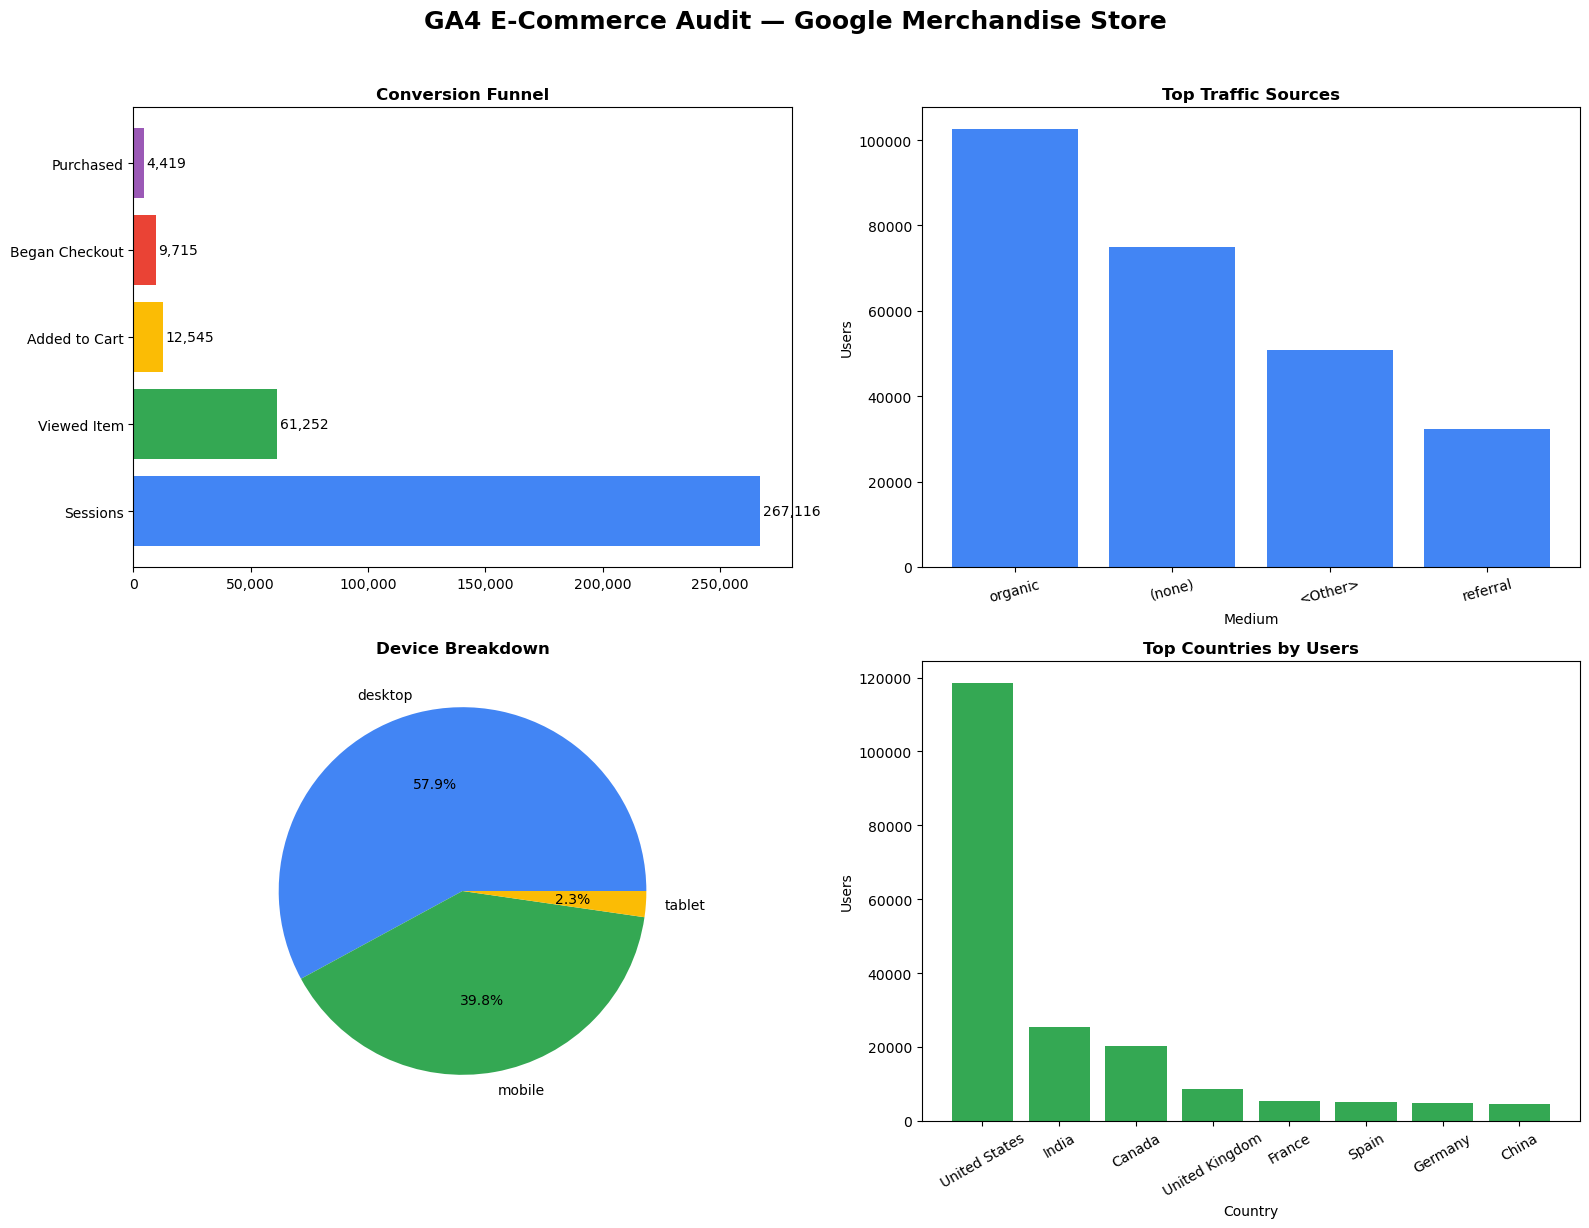

Chart saved!


In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('GA4 E-Commerce Audit — Google Merchandise Store', 
             fontsize=18, fontweight='bold', y=1.02)

# 1. Conversion Funnel
stages = ['Sessions', 'Viewed Item', 'Added to Cart', 'Began Checkout', 'Purchased']
values = [267116, 61252, 12545, 9715, 4419]
colors = ['#4285F4', '#34A853', '#FBBC05', '#EA4335', '#9B59B6']
axes[0,0].barh(stages, values, color=colors)
axes[0,0].set_title('Conversion Funnel', fontweight='bold')
axes[0,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(values):
    axes[0,0].text(v + 1000, i, f'{v:,}', va='center')

# 2. Traffic Sources
top_sources = df_sources.head(5)
axes[0,1].bar(top_sources['medium'], top_sources['users'], color='#4285F4')
axes[0,1].set_title('Top Traffic Sources', fontweight='bold')
axes[0,1].set_xlabel('Medium')
axes[0,1].set_ylabel('Users')
axes[0,1].tick_params(axis='x', rotation=15)

# 3. Device Breakdown
axes[1,0].pie(df_devices['users'], labels=df_devices['device_type'], 
              autopct='%1.1f%%', colors=['#4285F4', '#34A853', '#FBBC05'])
axes[1,0].set_title('Device Breakdown', fontweight='bold')

# 4. Top Countries
top_countries = df_countries.head(8)
axes[1,1].bar(top_countries['country'], top_countries['users'], color='#34A853')
axes[1,1].set_title('Top Countries by Users', fontweight='bold')
axes[1,1].set_xlabel('Country')
axes[1,1].set_ylabel('Users')
axes[1,1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('ga4_audit_visuals.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

## Key Findings

### 1. Conversion Funnel — Critical Drop-off Points
Out of 267,116 sessions, only 4,419 resulted in a purchase — 
a conversion rate of just 1.6%. The biggest drop occurs between 
sessions and product views (77% of visitors never view a product), 
suggesting homepage engagement and navigation need improvement.

### 2. Traffic Sources — Over-reliance on Organic Search
Organic Google drives 102,530 users — the dominant channel by far. 
Direct traffic is second at 75,025. This heavy dependence on a 
single channel is a risk — any Google algorithm change could 
significantly impact traffic.

### 3. Device — Desktop Dominates Unexpectedly
57.9% of users visit via desktop, which is unusual for modern 
e-commerce. This suggests the audience skews professional/older, 
and the mobile experience may be underoptimized.

### 4. Geography — US-Centric with Global Potential
118,493 users from the US vs 25,367 from India suggests 
untapped international growth potential, particularly in 
English-speaking markets like Canada and UK.

C:\Users\Tugce\.conda\envs\DataAnalytics\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


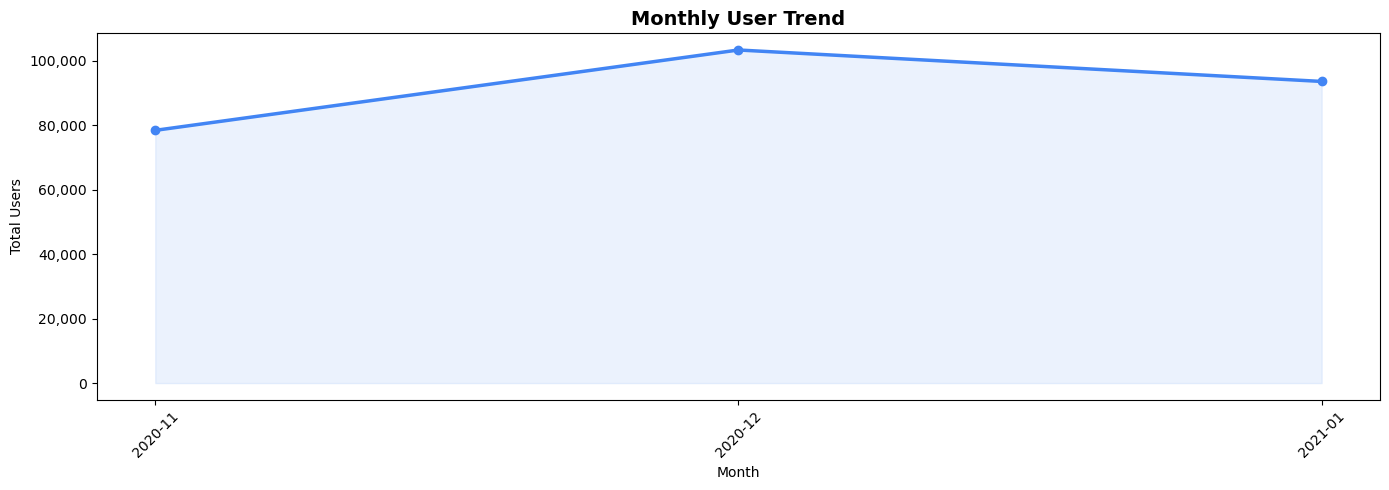

Saved!


In [6]:
# Monthly Users Trend
query_monthly = """
    SELECT
        FORMAT_DATE('%Y-%m', PARSE_DATE('%Y%m%d', event_date)) AS month,
        COUNT(DISTINCT user_pseudo_id) AS total_users
    FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
    WHERE event_name = 'session_start'
    GROUP BY month
    ORDER BY month
"""

df_monthly = client.query(query_monthly).to_dataframe()

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_monthly['month'], df_monthly['total_users'], 
        marker='o', linewidth=2.5, color='#4285F4', markersize=6)
ax.fill_between(df_monthly['month'], df_monthly['total_users'], 
                alpha=0.1, color='#4285F4')
ax.set_title('Monthly User Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Users')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('ga4_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")